# Exploratory 2 — EDA & Maps (Data Bersih)

Exploratory Data Analysis and map visualizations using cleaned village-level data (BPS + PODES + IUP flag) from **Data/DATA_BERSIH**.

Written by: Atha Bintang Wahyu M.

In [1]:
# Setup: paths and imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

BASE = Path("/Users/athamawardi/Desktop/Research-Projects/KRE_Equity")
DATA_BERSIH = BASE / "Data" / "DATA_BERSIH"
adm4_files = sorted(DATA_BERSIH.glob("adm4_podes_*_with_iup_flag.gpkg"))
print("Available adm4 files:", [f.name for f in adm4_files])


Available adm4 files: ['adm4_podes_2011_with_iup_flag.gpkg', 'adm4_podes_2014_with_iup_flag.gpkg', 'adm4_podes_2018_with_iup_flag.gpkg', 'adm4_podes_2019_with_iup_flag.gpkg', 'adm4_podes_2020_with_iup_flag.gpkg', 'adm4_podes_2021_with_iup_flag.gpkg', 'adm4_podes_2024_with_iup_flag.gpkg']


In [2]:
# Load 2024 village-level data (primary EDA); optionally load another year for panel
gdf = gpd.read_file(DATA_BERSIH / "adm4_podes_2024_with_iup_flag.gpkg")
print("Shape:", gdf.shape)
print("CRS:", gdf.crs)
gdf.head(2)


Shape: (81912, 846)
CRS: EPSG:4326


,Shape_Leng,Shape_Area,ADM4_EN,ADM4_PCODE,ADM4_REF,ADM4ALT1EN,ADM4ALT2EN,ADM3_EN,ADM3_PCODE,ADM2_EN,...,n_clascmd_4,n_clascmd_5,n_clascmd_6,iup_year_min,iup_year_max,iup_datend_year_min,iup_datend_year_max,area_hectares_iup,pct_iup_coverage,geometry
0,0.096387,0.000169,1 Ilir,ID1671060006,None,None,None,Ilir Timur II,ID1671060,Kota Palembang,...,0,3,0,2018.0,2018.0,2023.0,2023.0,2.148031,1.033204,"MULTIPOLYGON (((104.82248 -2.98102, 104.82165 ..."
1,0.018611,0.000017,1 Ulu,ID1671020008,None,None,None,Seberang Ulu I,ID1671020,Kota Palembang,...,0,0,0,NaN,NaN,NaN,NaN,0.000000,0.000000,"MULTIPOLYGON (((104.75516 -3.01316, 104.7548 -..."


## 1. Data structure and missing values

In [3]:
# Basic info
print(gdf.info())
print("\n--- Missing (top 20) ---")
miss = gdf.isnull().sum().sort_values(ascending=False)
print(miss[miss > 0].head(20))


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 81912 entries, 0 to 81911
Columns: 846 entries, Shape_Leng to geometry
dtypes: datetime64[ms](3), float64(741), geometry(1), int64(27), object(74)
memory usage: 528.7+ MB
None

--- Missing (top 20) ---
validTo                81912
ADM4ALT2EN             81912
ADM4ALT1EN             81901
ADM4_REF               81780
iup_datend_year_max    77100
iup_datend_year_min    77100
iup_year_min           77099
iup_year_max           77099
R1004                   4789
R1005D                  4789
R1005C                  4789
R1005B                  4789
R1005A                  4789
R711FK3                 4789
R1003B                  4789
R1003A                  4789
R1006B                  4789
R1002DK7                4789
R1002DK6B               4789
R1006A                  4789
dtype: int64


### Key columns (IUP & identifiers)

In [4]:
key_cols = ["id_desa_numeric", "NAMA_PROV", "NAMA_KAB", "NAMA_KEC", "NAMA_DESA", "has_iup",
         "n_wiup", "area_hectares_iup", "pct_iup_coverage"]
key = [c for c in key_cols if c in gdf.columns]
gdf[key].describe(include="all")


,id_desa_numeric,NAMA_PROV,NAMA_KAB,NAMA_KEC,NAMA_DESA,has_iup,n_wiup,area_hectares_iup,pct_iup_coverage
count,8.191200e+04,77123,77123,77123,77123,81912.000000,81912.000000,81912.000000,81912.000000
unique,NaN,34,463,6244,57826,NaN,NaN,NaN,NaN
top,NaN,JAWA TENGAH,ACEH UTARA,DOLOK,SIDOMULYO,NaN,NaN,NaN,NaN
freq,NaN,8529,852,86,93,NaN,NaN,NaN,NaN
mean,4.182139e+09,NaN,NaN,NaN,NaN,0.058758,0.173332,33.660108,0.582242
std,2.572800e+09,NaN,NaN,NaN,NaN,0.235173,1.060149,531.215471,4.559899
min,1.101010e+09,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
25%,1.673030e+09,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
50%,3.501100e+09,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000
75%,6.309081e+09,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000


## 2. Target variable: has_iup

In [5]:
# Villages with vs without IUP
print(gdf["has_iup"].value_counts().to_string())
print("\nShare with IUP: {:.2%}".format(gdf["has_iup"].mean()))


has_iup
0    77099
1     4813

Share with IUP: 5.88%


## 3. Numeric EDA — IUP aggregates (villages with IUP)

In [6]:
# Among villages with IUP
with_iup = gdf[gdf["has_iup"] == 1]
for col in ["n_wiup", "area_hectares_iup", "pct_iup_coverage"]:
    if col not in with_iup.columns:
        continue
    print(f"--- {col} ---")
    print(with_iup[col].describe().to_string())
    print()


--- n_wiup ---
count    4813.000000
mean        2.949927
std         3.307431
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        77.000000

--- area_hectares_iup ---
count     4813.000000
mean       572.858247
std       2120.036418
min          0.000000
25%          6.102038
50%         44.598147
75%        334.016754
max      82509.377534

--- pct_iup_coverage ---
count    4813.000000
mean        9.909127
std        16.170883
min         0.000000
25%         0.461339
50%         2.730594
75%        12.095051
max       159.033476



## 4. Categorical EDA — Province and district

In [7]:
# Count by province
prov_counts = gdf["NAMA_PROV"].value_counts()
print("Top 15 provinces (all villages):")
print(prov_counts.head(15).to_string())
print("\nVillages with IUP by province:")
iup_by_prov = gdf.groupby("NAMA_PROV")["has_iup"].agg(["sum", "count"]).assign(pct=lambda x: x["sum"]/x["count"]*100)
iup_by_prov = iup_by_prov.sort_values("sum", ascending=False)
print(iup_by_prov.head(15).to_string())


Top 15 provinces (all villages):
NAMA_PROV
JAWA TENGAH            8529
JAWA TIMUR             8492
ACEH                   6500
SUMATERA UTARA         6033
JAWA BARAT             5957
NUSA TENGGARA TIMUR    3246
SUMATERA SELATAN       3206
SULAWESI SELATAN       3010
LAMPUNG                2630
SULAWESI TENGGARA      2271
KALIMANTAN BARAT       2132
SULAWESI TENGAH        1984
KALIMANTAN SELATAN     1962
SULAWESI UTARA         1836
RIAU                   1833

Villages with IUP by province:
                           sum  count        pct
NAMA_PROV                                       
SUMATERA SELATAN           385   3206  12.008734
KALIMANTAN TENGAH          363   1570  23.121019
JAWA TIMUR                 355   8492   4.180405
KALIMANTAN SELATAN         345   1962  17.584098
KALIMANTAN TIMUR           344   1012  33.992095
JAWA TENGAH                280   8529   3.282917
KALIMANTAN BARAT           260   2132  12.195122
SULAWESI TENGGARA          256   2271  11.272567
SULAWESI TENGAH

## 5. Visualizations

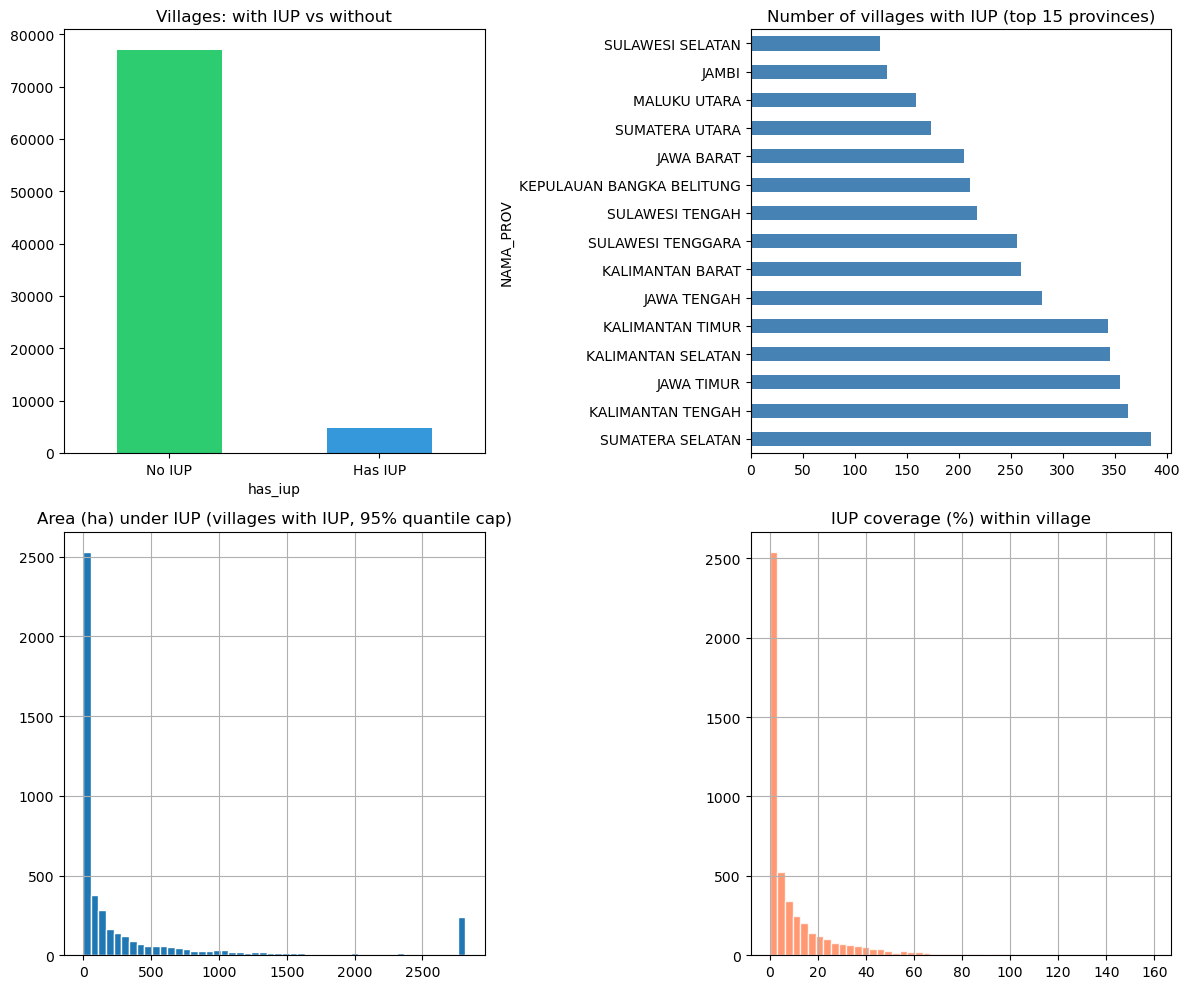

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
with_iup = gdf[gdf["has_iup"] == 1]

# 1) has_iup bar
gdf["has_iup"].value_counts().sort_index().plot(kind="bar", ax=axes[0,0], color=["#2ecc71","#3498db"])
axes[0,0].set_title("Villages: with IUP vs without")
axes[0,0].set_xticklabels(["No IUP", "Has IUP"], rotation=0)

# 2) IUP share by province (top 15)
iup_by_prov.head(15)["sum"].plot(kind="barh", ax=axes[0,1], color="steelblue")
axes[0,1].set_title("Number of villages with IUP (top 15 provinces)")

# 3) Distribution of IUP area (has_iup==1)
if "area_hectares_iup" in gdf.columns and len(with_iup) > 0:
    with_iup["area_hectares_iup"].clip(upper=with_iup["area_hectares_iup"].quantile(0.95)).hist(ax=axes[1,0], bins=50, edgecolor="white")
    axes[1,0].set_title("Area (ha) under IUP (villages with IUP, 95% quantile cap)")

# 4) Distribution of pct_iup_coverage
if "pct_iup_coverage" in gdf.columns and len(with_iup) > 0:
    with_iup["pct_iup_coverage"].hist(ax=axes[1,1], bins=50, edgecolor="white", color="coral", alpha=0.8)
    axes[1,1].set_title("IUP coverage (%) within village")

plt.tight_layout()
plt.show()


## 6. Maps

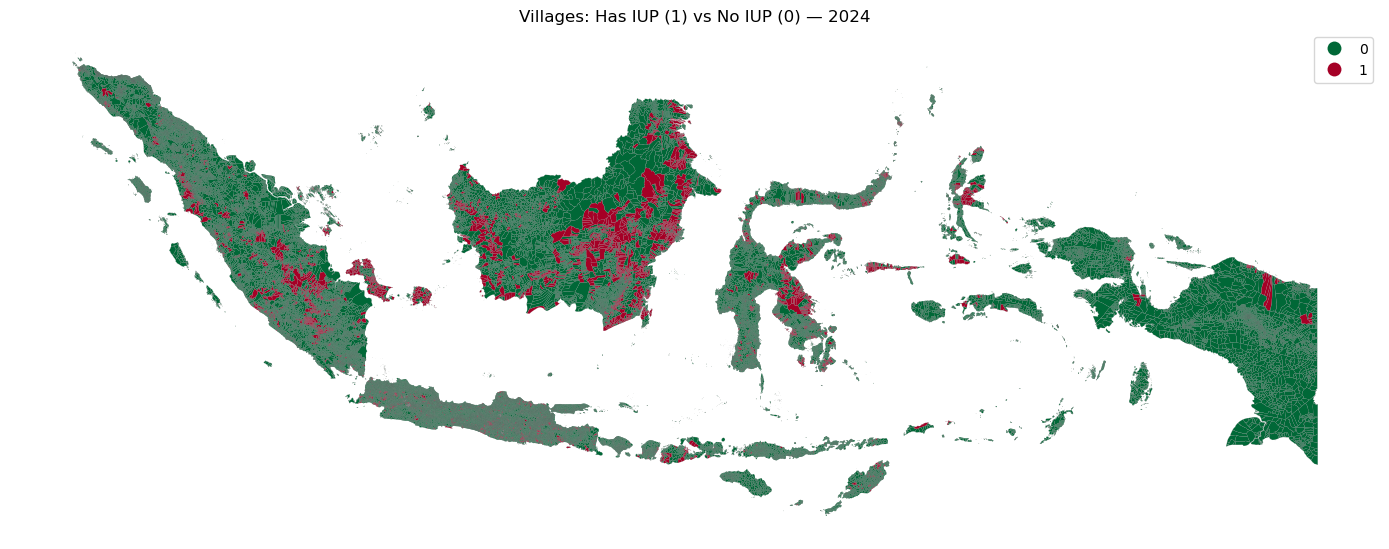

In [9]:
# Simplify geometry for faster plotting (optional)
gdf_plot = gdf.copy()
if gdf_plot.crs is None:
    gdf_plot.set_crs(4326, inplace=True)

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
gdf_plot.plot(column="has_iup", categorical=True, legend=True, ax=ax, cmap="RdYlGn_r", linewidth=0.1, edgecolor="gray")
ax.set_title("Villages: Has IUP (1) vs No IUP (0) — 2024")
ax.axis("off")
plt.tight_layout()
plt.show()


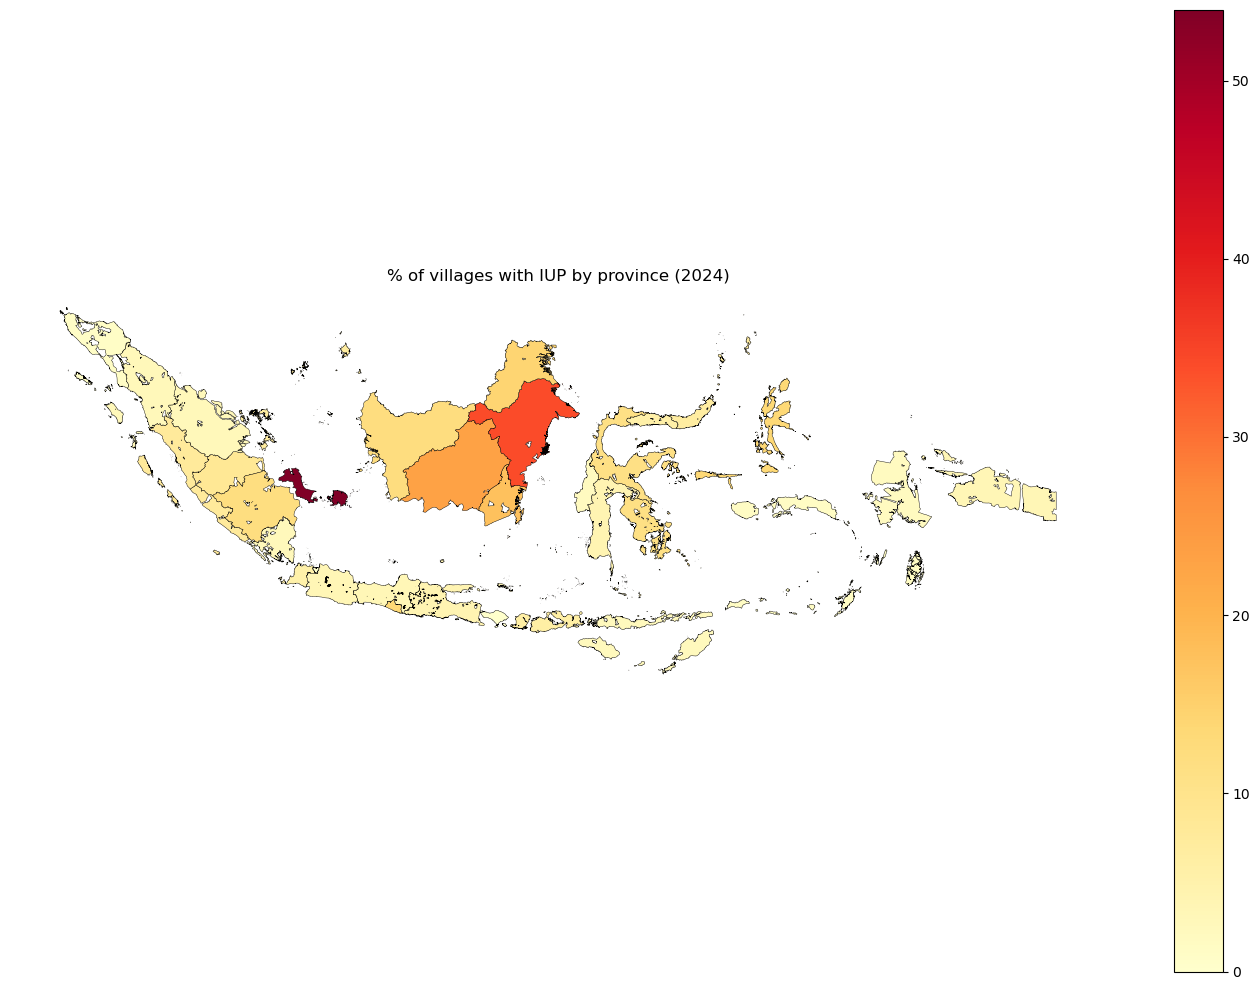

In [10]:
# Choropleth: share of villages with IUP by province
prov_agg = gdf.groupby("NAMA_PROV").agg(
    has_iup_sum=("has_iup", "sum"),
    total=("has_iup", "count")
).reset_index()
prov_agg["pct_iup"] = prov_agg["has_iup_sum"] / prov_agg["total"] * 100
# Dissolve to province and join
gdf_prov = gdf.dissolve(by="NAMA_PROV", aggfunc="first").reset_index()
gdf_prov = gdf_prov.merge(prov_agg[["NAMA_PROV", "pct_iup", "has_iup_sum"]], on="NAMA_PROV", how="left")

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
gdf_prov.plot(column="pct_iup", legend=True, ax=ax, cmap="YlOrRd", edgecolor="black", linewidth=0.3)
ax.set_title("% of villages with IUP by province (2024)")
ax.axis("off")
plt.tight_layout()
plt.show()


## 7. Panel snapshot: villages with IUP by year


   year  total  with_iup       pct
0  2011  83862       880  1.049343
1  2014  81912      4846  5.916105
2  2018  81912      4902  5.984471
3  2019  81912      4853  5.924651
4  2020  81912      4856  5.928313
5  2021  81912      4830  5.896572
6  2024  81912      4813  5.875818


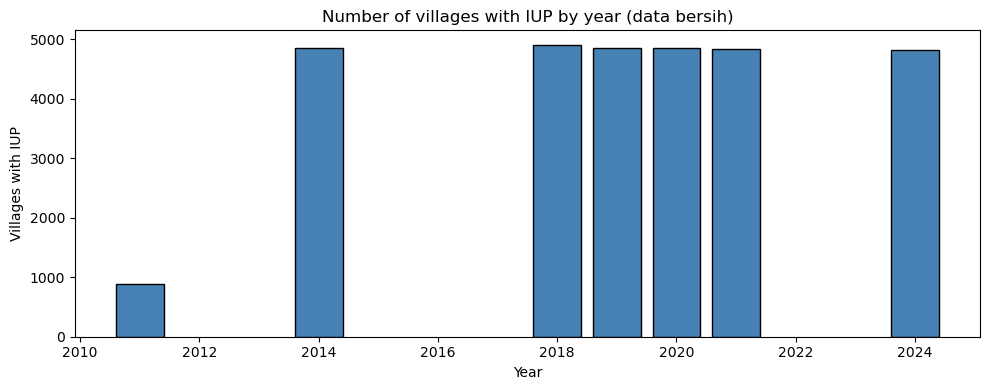

In [11]:
# Quick comparison across years (one row per year)
years = [2011, 2014, 2018, 2019, 2020, 2021, 2024]
rows = []
for y in years:
    p = DATA_BERSIH / f"adm4_podes_{y}_with_iup_flag.gpkg"
    if not p.exists():
        continue
    g = gpd.read_file(p)
    if "has_iup" not in g.columns:
        continue
    rows.append({"year": y, "total": len(g), "with_iup": g["has_iup"].sum(), "pct": g["has_iup"].mean() * 100})
panel = pd.DataFrame(rows)
print(panel.to_string())
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.bar(panel["year"], panel["with_iup"], color="steelblue", edgecolor="black")
ax.set_xlabel("Year")
ax.set_ylabel("Villages with IUP")
ax.set_title("Number of villages with IUP by year (data bersih)")
plt.tight_layout()
plt.show()


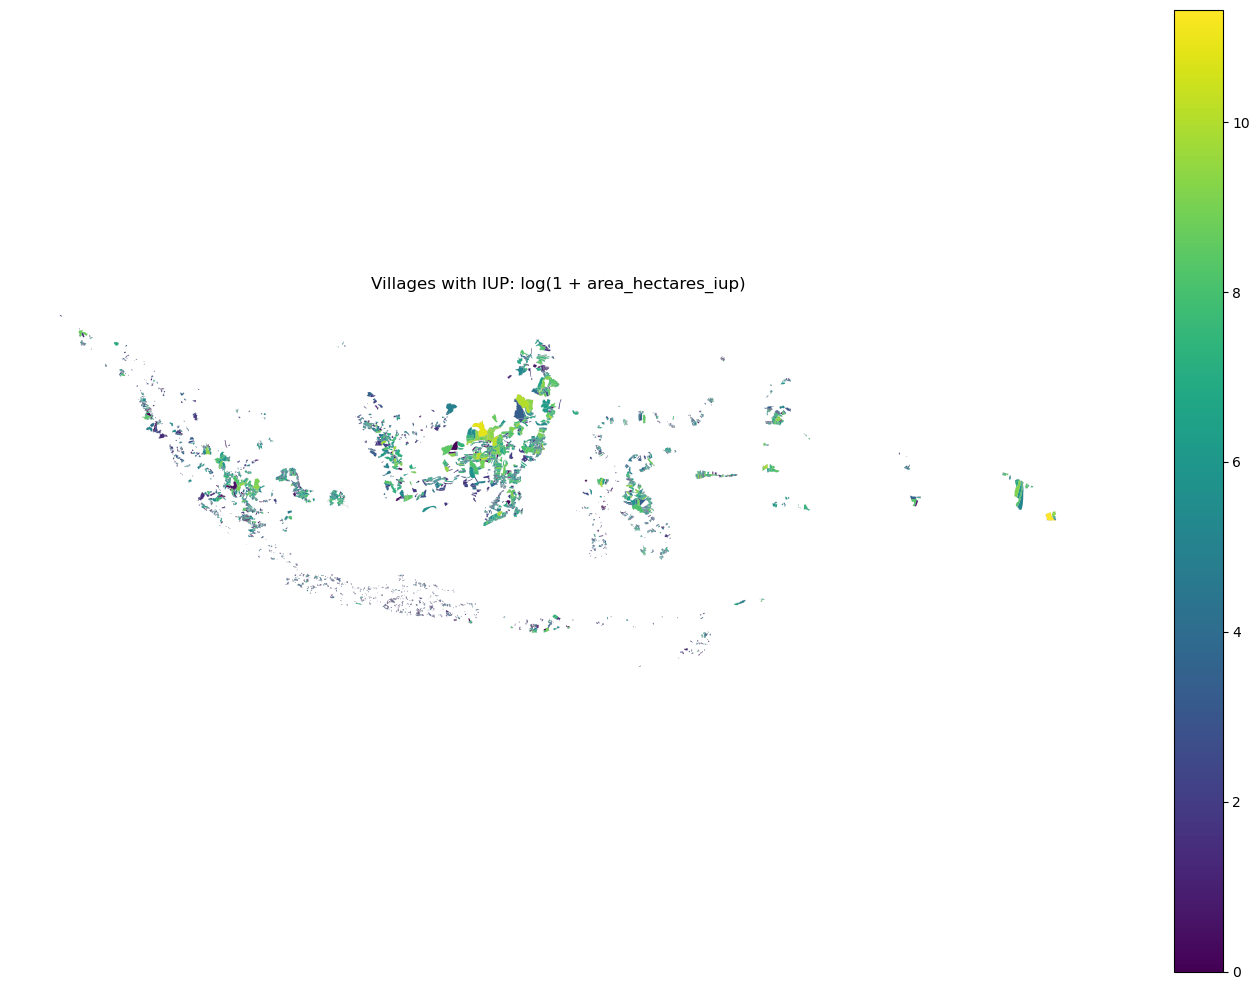

In [12]:
# Map: IUP area (ha) — villages with IUP only, log scale for visibility
with_iup_gdf = gdf[gdf["has_iup"] == 1].copy()
with_iup_gdf["area_log"] = np.log1p(with_iup_gdf["area_hectares_iup"].fillna(0))

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
with_iup_gdf.plot(column="area_log", legend=True, ax=ax, cmap="viridis", linewidth=0.05, edgecolor="gray")
ax.set_title("Villages with IUP: log(1 + area_hectares_iup)")
ax.axis("off")
plt.tight_layout()
plt.show()
